#📌 Extracción

In [310]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


Url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
Datos = pd.read_json(Url)
Datos.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

In [311]:
# Permite conocer la estructura del dataset
print("\nInformación del dataset:")
Datos.info()



Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [312]:
# Permite ver los tipos de datos de cada columna
print("\nTipos de datos:")
Datos.dtypes


Tipos de datos:


,0
customerID,object
Churn,object
customer,object
phone,object
internet,object
account,object


In [313]:
Datos = pd.concat([
    Datos.drop(['customer', 'phone','internet','account'], axis=1),
    pd.json_normalize(Datos['customer']),
    pd.json_normalize(Datos['phone']),
    pd.json_normalize(Datos['internet']),
    pd.json_normalize(Datos['account'])
], axis=1)

Datos.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [314]:
# Revisar valores únicos
print("Valores únicos por columna:")
for Columna in Datos.columns:
    print(f"\n{Columna}:")
    print(Datos[Columna].unique())

Valores únicos por columna:

customerID:
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']

Churn:
['No' 'Yes' '']

gender:
['Female' 'Male']

SeniorCitizen:
[0 1]

Partner:
['Yes' 'No']

Dependents:
['Yes' 'No']

tenure:
[ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]

PhoneService:
['Yes' 'No']

MultipleLines:
['No' 'Yes' 'No phone service']

InternetService:
['DSL' 'Fiber optic' 'No']

OnlineSecurity:
['No' 'Yes' 'No internet service']

OnlineBackup:
['Yes' 'No' 'No internet service']

DeviceProtection:
['No' 'Yes' 'No internet service']

TechSupport:
['Yes' 'No' 'No internet service']

StreamingTV:
['Yes' 'No' 'No internet service']

StreamingMovies:
['No' 'Yes' 'No internet service']

Contract:
['One year' 'Month-to-month' 'Two year']

PaperlessBilling:
['Yes' 'No']

Paymen

In [315]:
print("Información del nuevo dataset:")
Datos.info()

Información del nuevo dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract   

In [316]:
# Revisar valores nulos
print("Valores nulos:")
print(Datos.isnull().sum())

Valores nulos:
customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Charges.Monthly     0
Charges.Total       0
dtype: int64


In [317]:
# Permite verificar si existe algún dato duplicado y en caso de ser asi identificarlo para poder eliminarlo
print("Duplicados:")
Datos.duplicated().sum()

Duplicados:


np.int64(0)

In [318]:
# Estandarización de datos
ColumnasBinarias = [
    "Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"
]

for Columna in ColumnasBinarias:
    Datos[Columna] = Datos[Columna].replace({"Yes": 1, "No": 0})

Datos.head()

/tmp/ipykernel_430/2379333566.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Datos[Columna] = Datos[Columna].replace({"Yes": 1, "No": 0})


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,Yes,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.3
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.4
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.4


In [319]:
Datos["Cuentas_Diarias"] = Datos["Charges.Monthly"] /30
Datos.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total',
       'Cuentas_Diarias'],
      dtype='object')

In [320]:
Datos["Churn"] = Datos["Churn"].replace("", np.nan)
Datos = Datos.dropna(subset=["Churn"])

/tmp/ipykernel_430/2458967655.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Datos["Churn"] = Datos["Churn"].replace("", np.nan)


#📊 Carga y análisis

Se realizó un análisis descriptivo de las variables numéricas del dataset con el objetivo de comprender la distribución y comportamiento de los clientes. Para ello se calcularon métricas como media, mediana, desviación estándar, valores mínimos y máximos. Estas medidas permiten identificar patrones generales en variables como la antigüedad del cliente (tenure) y los cargos mensuales y totales.

In [321]:
Datos.describe()

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Cuentas_Diarias
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265370,0.162147,0.483033,0.299588,32.371149,0.903166,0.592219,64.761692,2.158723
std,0.441561,0.368612,0.499748,0.458110,24.559481,0.295752,0.491457,30.090047,1.003002
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.608333
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,1.183333
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,2.345000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.850000,2.995000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,3.958333


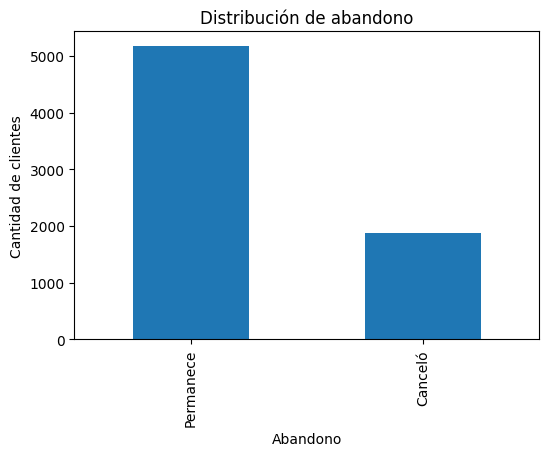

In [325]:
# Contar valores de churn
conteo_churn = Datos["Churn"].value_counts()

Datos["Churn"] = Datos["Churn"].replace({ 1: "Canceló", 0: "Permanece"})

# Gráfico de barras
plt.figure(figsize=(6,4))
conteo_churn.plot(kind="bar")

plt.title("Distribución de abandono")
plt.xlabel("Abandono")
plt.ylabel("Cantidad de clientes")

plt.show()

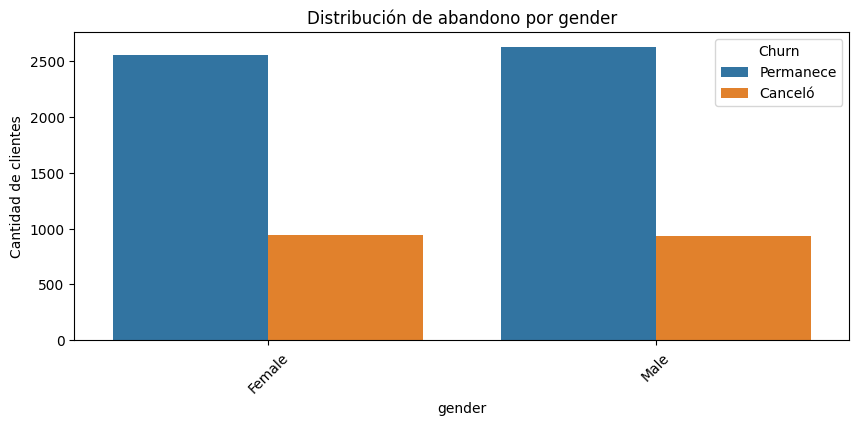

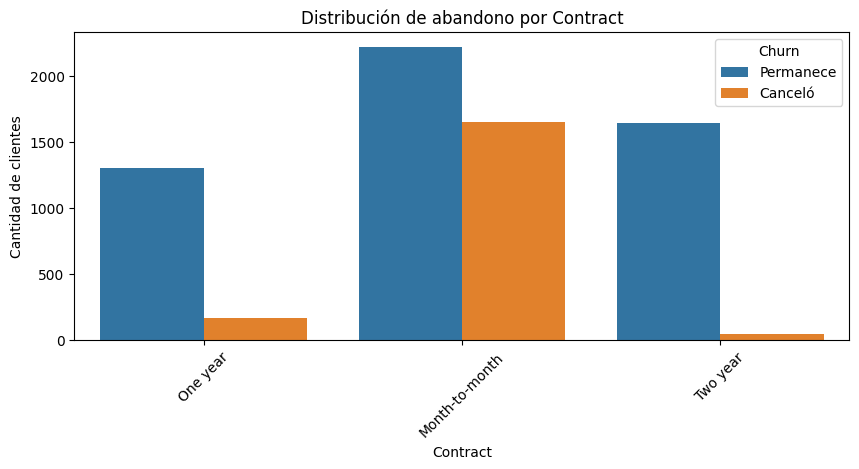

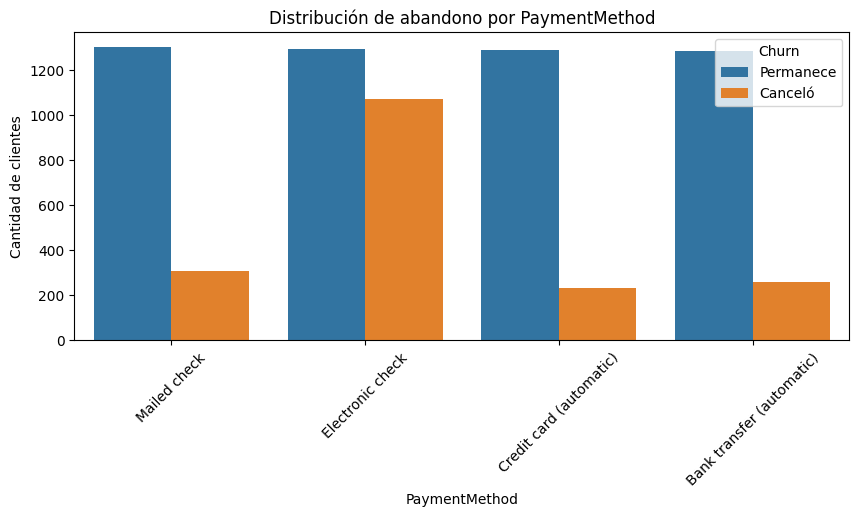

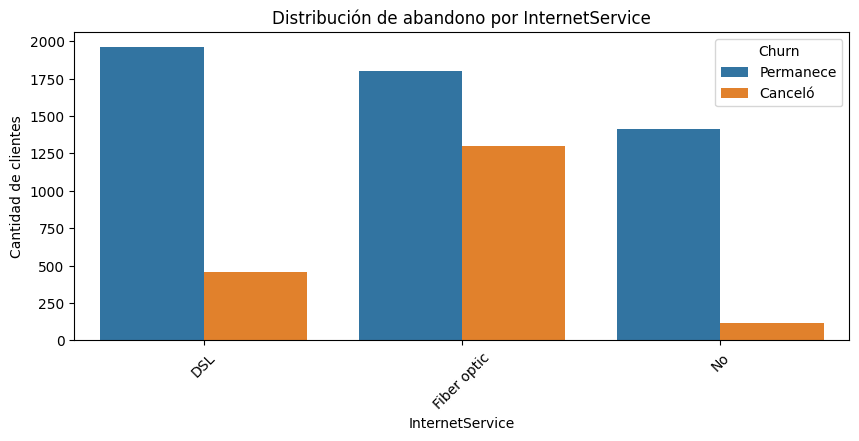

In [323]:
# Lista de variables categóricas
variables = ["gender", "Contract", "PaymentMethod", "InternetService"]

# Crear gráficos
for var in variables:
    plt.figure(figsize=(10,4))
    sns.countplot(data=Datos, x=var, hue="Churn")

    plt.title(f"Distribución de abandono por {var}")
    plt.xlabel(var)
    plt.ylabel("Cantidad de clientes")

    plt.xticks(rotation=45)
    plt.show()

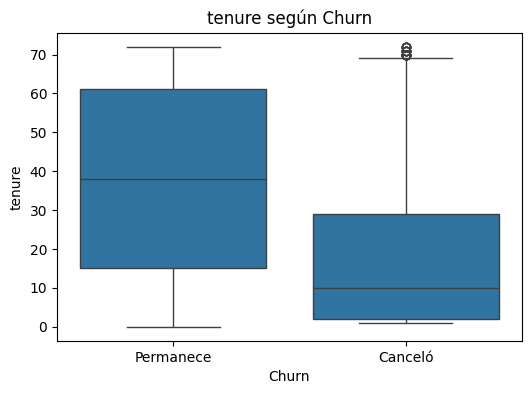

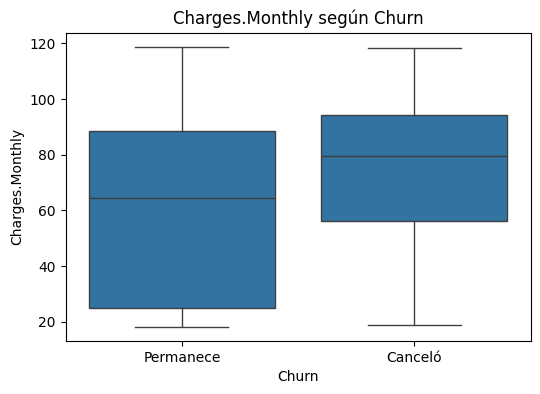

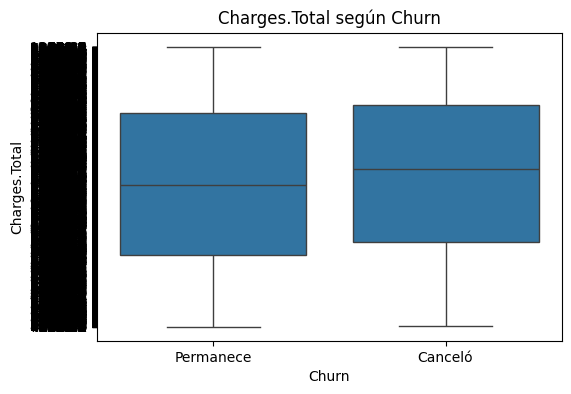

In [326]:
# Variables numéricas
variables_numericas = ["tenure", "Charges.Monthly", "Charges.Total"]

for var in variables_numericas:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=Datos, x="Churn", y=var)

    plt.title(f"{var} según Churn")
    plt.xlabel("Churn")
    plt.ylabel(var)
    print("\n")

    plt.show()

#📄Informe final

#🔹 Introducción

El objetivo de este análisis es identificar los factores asociados con la evasión de clientes (Churn) en la empresa TelecomX. La evasión de clientes representa un desafío importante para las empresas de servicios, ya que implica la pérdida de ingresos y mayores costos para adquirir nuevos clientes. A través del análisis de los datos se busca identificar patrones que permitan comprender mejor el comportamiento de los clientes y apoyar estrategias de retención.



---

#🔹 Limpieza y Tratamiento de Datos

Los datos fueron importados desde una fuente externa en formato JSON utilizando Python y la librería Pandas. Posteriormente, se realizó un proceso de limpieza y preparación de los datos, que incluyó la normalización de columnas anidadas, la verificación de valores nulos y duplicados, y la estandarización de algunas variables. Además, se creó una nueva variable llamada Cuentas_Diarias a partir de los cargos mensuales para facilitar el análisis.


---

#🔹 Análisis Exploratorio de Datos

Durante el análisis exploratorio se examinó la distribución de la variable Churn para identificar la proporción de clientes que permanecen y los que cancelan el servicio. También se analizaron variables categóricas como el tipo de contrato, método de pago y servicio de internet, así como variables numéricas como la antigüedad del cliente (tenure) y los cargos mensuales. Los gráficos permitieron identificar patrones relacionados con la evasión.



---

#🔹 Conclusiones e Insights

El análisis muestra que los clientes con contratos mensuales presentan una mayor tendencia a cancelar el servicio. Asimismo, se observa que los clientes con menor antigüedad y con cargos mensuales más altos tienen una mayor probabilidad de evasión.



---

#🔹 Recomendaciones

Se recomienda fortalecer las estrategias de fidelización para clientes con contratos mensuales, promover contratos de mayor duración y mejorar el acompañamiento a clientes nuevos. Estas acciones pueden contribuir a reducir la evasión y mejorar la retención de clientes.
